In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_weather = pd.read_csv('./weather_data.csv')
df_weather.head(10)

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/2/2017,NaN,7.0,Sunny
2,1/3/2017,28.0,NaN,Snow
3,1/4/2017,NaN,7.0,NaN
4,1/5/2017,32.0,NaN,Rain
5,1/6/2017,31.0,2.0,Sunny
6,1/6/2017,34.0,5.0,NaN


In [3]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          7 non-null      object 
 1   temperature  5 non-null      float64
 2   windspeed    5 non-null      float64
 3   event        5 non-null      object 
dtypes: float64(2), object(2)
memory usage: 352.0+ bytes


In [4]:
df_weather.isnull()

,day,temperature,windspeed,event
0,False,False,False,False
1,False,True,False,False
2,False,False,True,False
3,False,True,False,True
4,False,False,True,False
5,False,False,False,False
6,False,False,False,True


In [5]:
df_weather.isnull().sum()

day            0
temperature    2
windspeed      2
event          2
dtype: int64

In [6]:
df_weather.isnull().sum() / len(df_weather) * 100

day             0.000000
temperature    28.571429
windspeed      28.571429
event          28.571429
dtype: float64

In [7]:
df_weather.isnull().sum().sum()

np.int64(6)

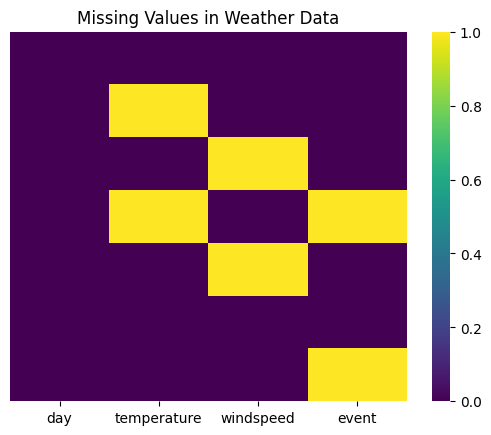

In [8]:
sns.heatmap(df_weather.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values in Weather Data')
plt.show()

In [9]:
df_weather.dropna()

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
5,1/6/2017,31.0,2.0,Sunny


In [10]:
df_weather.dropna(axis=1)

,day
0,1/1/2017
1,1/2/2017
2,1/3/2017
3,1/4/2017
4,1/5/2017
5,1/6/2017
6,1/6/2017


In [11]:
df_weather.dropna(how='all')

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/2/2017,NaN,7.0,Sunny
2,1/3/2017,28.0,NaN,Snow
3,1/4/2017,NaN,7.0,NaN
4,1/5/2017,32.0,NaN,Rain
5,1/6/2017,31.0,2.0,Sunny
6,1/6/2017,34.0,5.0,NaN


In [12]:
df_weather.dropna(thresh=3)

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/2/2017,NaN,7.0,Sunny
2,1/3/2017,28.0,NaN,Snow
4,1/5/2017,32.0,NaN,Rain
5,1/6/2017,31.0,2.0,Sunny
6,1/6/2017,34.0,5.0,NaN


In [13]:
df_weather.dropna(thresh=2)

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/2/2017,NaN,7.0,Sunny
2,1/3/2017,28.0,NaN,Snow
3,1/4/2017,NaN,7.0,NaN
4,1/5/2017,32.0,NaN,Rain
5,1/6/2017,31.0,2.0,Sunny
6,1/6/2017,34.0,5.0,NaN


In [14]:
df_weather.fillna(method='ffill')

C:\Users\tanis\AppData\Local\Temp\ipykernel_15052\275437121.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_weather.fillna(method='ffill')


,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/2/2017,32.0,7.0,Sunny
2,1/3/2017,28.0,7.0,Snow
3,1/4/2017,28.0,7.0,Snow
4,1/5/2017,32.0,7.0,Rain
5,1/6/2017,31.0,2.0,Sunny
6,1/6/2017,34.0,5.0,Sunny


In [15]:
df_weather['event'].fillna(df_weather['event'].mode()[0])

0     Rain
1    Sunny
2     Snow
3     Rain
4     Rain
5    Sunny
6     Rain
Name: event, dtype: object

In [16]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=2)

df_num = df_weather[['temperature', 'windspeed']]
df_filled = pd.DataFrame(imputer.fit_transform(df_num), columns=df_num.columns)
df_filled

,temperature,windspeed
0,32.0,6.0
1,33.0,7.0
2,28.0,4.0
3,33.0,7.0
4,32.0,4.0
5,31.0,2.0
6,34.0,5.0


In [17]:
data = {
    'age': [25, 30, 35, 40, 45, 50, 55, 60],
    'salary': [25000, 35000, 45000, 50000, 60000, 70000, 80000, 100000]
}

df_norm = pd.DataFrame(data)
df_norm

,age,salary
0,25,25000
1,30,35000
2,35,45000
3,40,50000
4,45,60000
5,50,70000
6,55,80000
7,60,100000


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_minmax = pd.DataFrame(scaler.fit_transform(df_norm), columns=df_norm.columns)
df_minmax

,age,salary
0,0.000000,0.000000
1,0.142857,0.133333
2,0.285714,0.266667
3,0.428571,0.333333
4,0.571429,0.466667
5,0.714286,0.600000
6,0.857143,0.733333
7,1.000000,1.000000
